In [1]:
import pandas as pd


In [2]:
df = pd.read_csv(
'https://archive.ics.uci.edu/ml/'
'machine-learning-databases'
'/breast-cancer-wisconsin/wdbc.data',
header=None
)

In [3]:
df.head()

,0,1,2,3,4,5,6,7,8,9,...,22,23,24,25,26,27,28,29,30,31
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [4]:
from sklearn.preprocessing import LabelEncoder

X = df.loc[:, 2:].values
y = df.loc[:, 1].values

le = LabelEncoder()
y = le.fit_transform(y)
le.classes_

array(['B', 'M'], dtype=object)

In [5]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=1)


In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline

In [7]:
pipe_lr = make_pipeline(
    StandardScaler(),
    PCA(n_components=2),
    LogisticRegression()

)

pipe_lr.fit(X_train, y_train)

y_pred = pipe_lr.predict(X_test)

test_acc = pipe_lr.score(X_test, y_test)
print(f'Test accuracy: {test_acc:.3f}')

Test accuracy: 0.956


In [8]:
import numpy as np
from sklearn.model_selection import StratifiedKFold
kfold = StratifiedKFold(n_splits=10).split(X_train, y_train)

scores = []

for k, (train, test) in enumerate(kfold):
    pipe_lr.fit(X_train[train], y_train[train])
    score = pipe_lr.score(X_train[test], y_train[test])
    scores.append(score)

    print(f'Fold: {k+1:02d} '
          f'Class distr: {np.bincount(y_train[train])}'
          f'Acc: {score:.3f}'
          
          )

Fold: 01 Class distr: [256 153]Acc: 0.935
Fold: 02 Class distr: [256 153]Acc: 0.935
Fold: 03 Class distr: [256 153]Acc: 0.957
Fold: 04 Class distr: [256 153]Acc: 0.957
Fold: 05 Class distr: [256 153]Acc: 0.935
Fold: 06 Class distr: [257 153]Acc: 0.956
Fold: 07 Class distr: [257 153]Acc: 0.978
Fold: 08 Class distr: [257 153]Acc: 0.933
Fold: 09 Class distr: [257 153]Acc: 0.956
Fold: 10 Class distr: [257 153]Acc: 0.956


In [9]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(estimator=pipe_lr,
                         X=X_train,
                         y=y_train,
                         cv=10,
                         n_jobs=1)

print(f'CV accuracy scores: {scores}')

print(f'CV accuracy: {np.mean(scores):.3f}'
      f' +/- {np.std(scores):.3f}'
      )

CV accuracy scores: [0.93478261 0.93478261 0.95652174 0.95652174 0.93478261 0.95555556
 0.97777778 0.93333333 0.95555556 0.95555556]
CV accuracy: 0.950 +/- 0.014


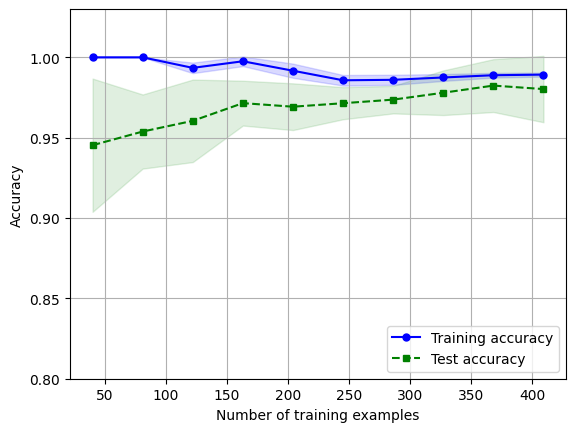

In [10]:
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve
pipe_lr = make_pipeline(
    StandardScaler(),
    LogisticRegression(l1_ratio=0)
)

train_sizes, train_scores, test_scores =\
            learning_curve(
                estimator=pipe_lr,
                X=X_train,
                y=y_train,
                train_sizes=np.linspace(0.1, 1.0, 10),
                cv=10,
                n_jobs=-1
            )
def plot_curves(x_axis,train_scores, test_scores):
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)
    plt.plot(
        x_axis, train_mean,
        color='blue', marker='o', 
        markersize=5, label='Training accuracy'
    )
    plt.fill_between(
        x_axis,
        train_mean + train_std,
        train_mean - train_std,
        alpha=0.15, color='blue'
    )

    plt.plot(
        x_axis, test_mean,
        color='green', marker='s', linestyle='--',
        markersize=5, label='Test accuracy'
    )

    plt.fill_between(
        x_axis,
        test_mean + test_std,
        test_mean - test_std,
        alpha=0.12, color='green'

    )

    plt.grid()
    plt.xlabel('Number of training examples')
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right')
    plt.ylim([0.8, 1.03])
    plt.show()

plot_curves(train_sizes,train_scores, test_scores)

In [11]:

pipe_lr = make_pipeline(
    StandardScaler(),
    LogisticRegression(l1_ratio=0)
)


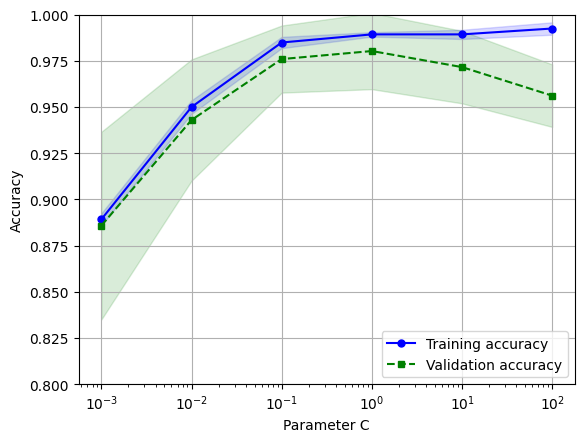

In [12]:
from sklearn.model_selection import validation_curve
param_range = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
train_scores, test_scores = validation_curve(
    estimator=pipe_lr,
    X=X_train,
    y=y_train,
    param_name='logisticregression__C',
    param_range=param_range,
    cv=10)
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)
plt.plot(param_range, train_mean,
         color='blue', marker='o',
         markersize=5, label='Training accuracy')
plt.fill_between(param_range, train_mean + train_std,
                 train_mean - train_std, alpha=0.15,
                 color='blue')
plt.plot(param_range, test_mean,
         color='green', linestyle='--',
         marker='s', markersize=5,
         label='Validation accuracy')
plt.fill_between(param_range,
                 test_mean + test_std,
                 test_mean - test_std,
                 alpha=0.15, color='green')
plt.grid()
plt.xscale('log')
plt.legend(loc='lower right')
plt.xlabel('Parameter C')
plt.ylabel('Accuracy')
plt.ylim([0.8, 1.0])
plt.show()

In [13]:
# Grid Search
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

pipe_svc = make_pipeline(
    StandardScaler(),
    SVC(random_state=1)
)


param_range = [0.0001, 0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]
parm_grid = [
    {'svc__C': param_range,
     'svc__kernel': ['linear']},
     {'svc__C': param_range,
      'svc__gamma': param_range,
      'svc__kernel': ['rbf']}
]


gs = GridSearchCV(estimator=pipe_svc,
                  param_grid=parm_grid,
                  scoring='accuracy',
                  cv=10,
                  refit=True,
                  n_jobs=-1)

gs = gs.fit(X_train, y_train)
print(gs.best_params_)
print(gs.best_score_)

{'svc__C': 100.0, 'svc__gamma': 0.001, 'svc__kernel': 'rbf'}
0.9846859903381642


In [14]:
clf = gs.best_estimator_
clf.fit(X_train, y_train)

print(f'Test Accuracy: {clf.score(X_test, y_test):.3f}')

Test Accuracy: 0.974


In [15]:
# Randomizde Search

import scipy.stats as sp
param_range = sp.loguniform(0.0001, 1000.0)



In [16]:
from sklearn.model_selection import RandomizedSearchCV
pipe_svc = make_pipeline(StandardScaler(),
                         SVC(random_state=1)
                         )
param_gird = [
     {'svc__C': param_range,
      'svc__kernel': ['linear']},
     {'svc__C': param_range,
      'svc__gamma': param_range,
      'svc__kernel': ['rbf']}
    
]

In [17]:
rs = RandomizedSearchCV(
    estimator=pipe_svc,
    param_distributions=param_gird,
    scoring='accuracy',
    refit=True,
    n_iter=20,
    cv=10,
    n_jobs=-1,
    random_state=1
)

rs.fit(X_train, y_train)

print(rs.best_score_)

print(rs.best_params_)

0.9780676328502416
{'svc__C': np.float64(0.05971247755848463), 'svc__kernel': 'linear'}


In [18]:
from sklearn.experimental import enable_halving_search_cv


In [19]:
from sklearn.model_selection import HalvingRandomSearchCV
hs = HalvingRandomSearchCV(pipe_svc, param_distributions=param_gird,
                           n_candidates='exhaust',
                           resource='n_samples',
                           factor=1.5,
                           random_state=1,
                           n_jobs=-1)

In [20]:
hs = hs.fit(X_train, y_train)
print(hs.best_score_)

0.9617647058823529


In [21]:
print(hs.best_params_)

{'svc__C': np.float64(4.934834261073333), 'svc__kernel': 'linear'}


In [22]:
clf = hs.best_estimator_
print(f'Test accuracy: {clf.score(X_test, y_test):.3f}')

Test accuracy: 0.982


In [24]:
# Hyperopt tuning
import warnings
# Silence Hyperopt's pkg_resources deprecation warning to keep notebook output clean.
warnings.filterwarnings('ignore', category=UserWarning)
from hyperopt import STATUS_OK, Trials, fmin, hp, space_eval, tpe
from sklearn.base import clone


pipe_svc = make_pipeline(StandardScaler(), SVC(random_state=1))

search_space = hp.choice(
    'svc_kernel_space',
    [
        {
            'kernel': 'linear',
            'C': hp.loguniform('linear_C', np.log(1e-4), np.log(1e3)),
        },
        {
            'kernel': 'rbf',
            'C': hp.loguniform('rbf_C', np.log(1e-4), np.log(1e3)),
            'gamma': hp.loguniform('rbf_gamma', np.log(1e-4), np.log(1e3)),
        },
    ],
)

def objective(params):
    model = clone(pipe_svc)
    model.set_params(
        svc__kernel=params['kernel'],
        svc__C=params['C'],
        **({'svc__gamma': params['gamma']} if 'gamma' in params else {}),
    )

    score = cross_val_score(
        estimator=model,
        X=X_train,
        y=y_train,
        cv=5,
        scoring='accuracy',
        n_jobs=-1,
    ).mean()

    return {'loss': -score, 'status': STATUS_OK}

trials = Trials()
best = fmin(
    fn=objective,
    space=search_space,
    algo=tpe.suggest,
    max_evals=30,
    trials=trials,
    rstate=np.random.default_rng(1),
)

best_params = space_eval(search_space, best)
print('Best params:', best_params)
print('Best CV accuracy:', -min(t['result']['loss'] for t in trials.trials))

hyperopt_clf = clone(pipe_svc)
hyperopt_clf.set_params(
    svc__kernel=best_params['kernel'],
    svc__C=best_params['C'],
    **({'svc__gamma': best_params['gamma']} if 'gamma' in best_params else {}),
)
hyperopt_clf.fit(X_train, y_train)
print(f"Hyperopt test accuracy: {hyperopt_clf.score(X_test, y_test):.3f}")

100%|██████████| 30/30 [00:00<00:00, 67.19trial/s, best loss: -0.9802197802197803]
Best params: {'C': 0.1706128775241855, 'kernel': 'linear'}
Best CV accuracy: 0.9802197802197803
Hyperopt test accuracy: 0.974


## Choosing a tuning strategy
- **GridSearchCV**: best when the search space is small and you want exhaustive, reproducible coverage.
- **RandomizedSearchCV**: best when the space is large; good baseline with fixed compute budget.
- **HalvingRandomSearchCV**: best when model training is expensive and you want early elimination of weak configs.
- **Hyperopt (TPE)**: best when the search space is large/conditional (like `kernel -> gamma`) and you want smarter, adaptive sampling.

### Rule of thumb
- Start with `RandomizedSearchCV` for a quick baseline.
- Move to `Hyperopt` when you want better results under the same or lower `max_evals`.
- Keep a held-out test set untouched until final model selection (as done above).

In [25]:
## Nested cross validation
param_range = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]
param_gird = [
     {'svc__C': param_range,
      'svc__kernel': ['linear']},
     {'svc__C': param_range,
      'svc__gamma': param_range,
      'svc__kernel': ['rbf']}
    
]

In [26]:
gs = GridSearchCV(estimator=pipe_svc, 
                  param_grid=param_gird,
                  scoring='accuracy',
                  cv=2)

In [28]:
scores = cross_val_score(gs, X_train, y_train, scoring='accuracy', cv=5)
print(f'CV accuracy: {np.mean(scores):.3f}'
      f' +/- {np.std(scores):.3f}')

CV accuracy: 0.974 +/- 0.015


In [29]:
from sklearn.tree import DecisionTreeClassifier
gs = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=0),
    param_grid=[{'max_depth': [1, 2, 3, 4, 5, 6, 7, None]}],
    scoring='accuracy',
    cv=2
)

scores = cross_val_score(gs, X_train, y_train, scoring='accuracy', cv=5)
print(f'CV accuracy: {np.mean(scores):.3f}'
      f' +/- {np.std(scores):.3f}')


CV accuracy: 0.934 +/- 0.016


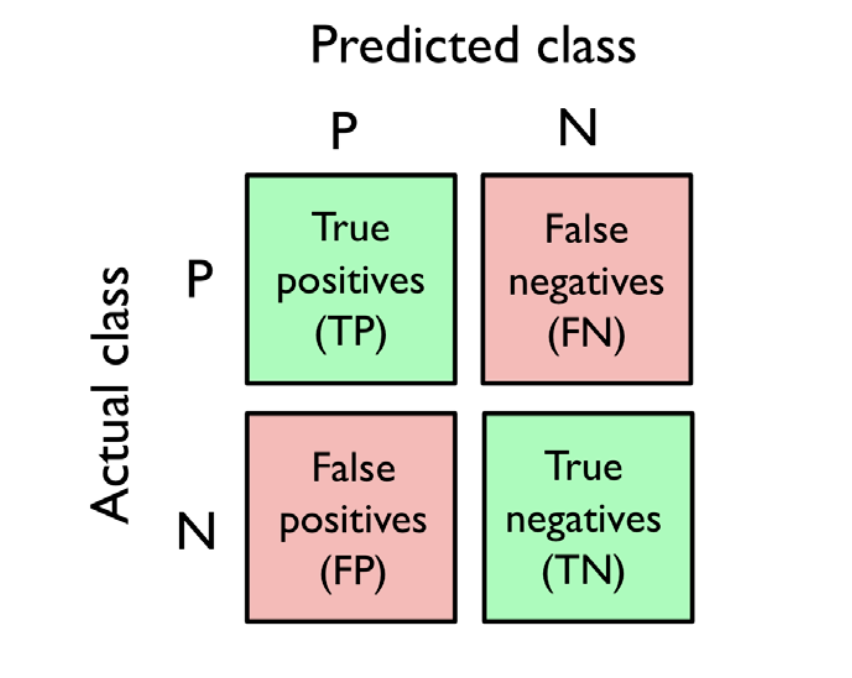

In [30]:
from sklearn.metrics import confusion_matrix
pipe_svc.fit(X_train, y_train)
y_pred = pipe_svc.predict(X_test)
confmat = confusion_matrix(y_true=y_test, y_pred=y_pred)
print(confmat)

[[71  1]
 [ 2 40]]


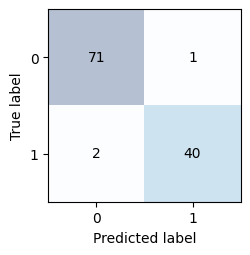

In [31]:
fig, ax = plt.subplots(figsize=(2.5, 2.5))
ax.matshow(confmat, cmap=plt.cm.Blues, alpha=0.3)
for i in range(confmat.shape[0]):
    for j in range(confmat.shape[1]):
        ax.text(x =j, y=i, s=confmat[i, j], va='center', ha='center')
ax.xaxis.set_ticks_position('bottom')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.show()

## Classification Metric Formulations

### Confusion matrix (2×2)

|                | Predicted Positive | Predicted Negative |
|----------------|--------------------|--------------------|
| Actual Positive | $TP$               | $FN$               |
| Actual Negative | $FP$               | $TN$               |

Let:
- $TP$: true positives
- $TN$: true negatives
- $FP$: false positives
- $FN$: false negatives
- $N = TP + TN + FP + FN$

### Prediction Error (Error Rate)
$$
\text{Prediction Error} = \frac{FP + FN}{N}
$$

### Accuracy
$$
\text{Accuracy} = \frac{TP + TN}{N}
$$

### True Positive Rate (TPR / Sensitivity)
$$
\text{TPR} = \frac{TP}{TP + FN}
$$

### Precision
$$
\text{Precision} = \frac{TP}{TP + FP}
$$

### Recall
$$
\text{Recall} = \frac{TP}{TP + FN}
$$

### F1-score
$$
F_1 = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}
$$

Equivalent form:
$$
F_1 = \frac{2TP}{2TP + FP + FN}
$$

### Matthews Correlation Coefficient (MCC)
$$
\mathrm{MCC} = \frac{TP \cdot TN - FP \cdot FN}{\sqrt{(TP+FP)(TP+FN)(TN+FP)(TN+FN)}}
$$

- Range: $[-1, 1]$
- $1$: perfect prediction, $0$: random-level prediction, $-1$: total disagreement

In [32]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef

if 'hyperopt_clf' in globals():
    eval_model = hyperopt_clf
elif 'clf' in globals():
    eval_model = clf
else:
    raise NameError("No trained model found. Run a training/tuning cell first.")

y_pred_metrics = eval_model.predict(X_test)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_metrics).ravel()
n = tp + tn + fp + fn

prediction_error = (fp + fn) / n
accuracy = accuracy_score(y_test, y_pred_metrics)
tpr = tp / (tp + fn) if (tp + fn) > 0 else 0.0
precision = precision_score(y_test, y_pred_metrics, zero_division=0)
recall = recall_score(y_test, y_pred_metrics, zero_division=0)
f1 = f1_score(y_test, y_pred_metrics, zero_division=0)
mcc = matthews_corrcoef(y_test, y_pred_metrics)

print(f"Prediction Error: {prediction_error:.4f}")
print(f"Accuracy:         {accuracy:.4f}")
print(f"TPR:              {tpr:.4f}")
print(f"Precision:        {precision:.4f}")
print(f"Recall:           {recall:.4f}")
print(f"F1-score:         {f1:.4f}")
print(f"MCC:              {mcc:.4f}")

Prediction Error: 0.0263
Accuracy:         0.9737
TPR:              0.9524
Precision:        0.9756
Recall:           0.9524
F1-score:         0.9639
MCC:              0.9433
